# 4주차 — LSTM 분위수 회귀 + LSTM-SHAP 검증

> 계획서 v5.1 §5.2 + §6.2 · 검증 포인트: **분위수 출력 검증 + monotonicity 점검 + SHAP 동작**

## 본 노트북의 목표

| 작업 | 계획서 근거 | 산출물 |
|------|------------|--------|
| 1. 다변량 LSTM 분위수 회귀 (q=0.05/0.5/0.95 동시 출력) | §5.2 | `models/lstm_quantile_w4.pt` |
| 2. Pinball Loss + sort 후처리 + monotonicity 점검 | §5.3 | `reports/lstm_quantile_eval_w4.csv` |
| 3. Train/Val loss curve | §5.7 | `reports/figures/w4_01_loss_curve.png` |
| 4. **LSTM-SHAP DeepExplainer** (실패 시 Permutation Importance) | §6.2 | `reports/figures/w4_03_lstm_shap_*.png` |
| 5. Naive/ARIMA/XGBoost(W3) vs LSTM 비교 | §9 | `reports/baseline_results_w4.csv` |

## 입력 (3주차 산출물)

- `data/processed/features_v1_candidate.csv` — 9 freeze 변수 + 타겟 (raw)
- `data/processed/features_with_lags_v1.csv` — Lag/Rolling + 라벨 (Δy)
- `models/scaler_robust_train.pkl` — train-fit RobustScaler
- `data/processed/xgb_predictions_w3.csv` — XGBoost val/test 예측
- `reports/baseline_results_w3.csv` — Naive/ARIMA/XGBoost 비교
- `docs/freeze_final_w3.md` — 8 vars freeze

## LSTM 입력 텐서 설계 (§5.2)

- 입력: `(samples, 30 timesteps, 8 features)` — 8개 raw scaled feature × 30 영업일 lookback
- 출력: `[q_0.05, q_0.5, q_0.95]` 동시 (multi-output head)
- 손실: Pinball loss 합산

---

## 0. 환경 설정

In [1]:
import importlib.util, subprocess, sys
REQUIRED = {
    'torch':       'torch',
    'shap':        'shap',
    'sklearn':     'scikit-learn',
    'matplotlib':  'matplotlib',
    'yaml':        'pyyaml',
}
for _name, _pip in REQUIRED.items():
    if importlib.util.find_spec(_name) is None:
        # torch 는 CPU 휠 인덱스 사용 (사용자 환경)
        if _pip == 'torch':
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                                   'torch', '--index-url', 'https://download.pytorch.org/whl/cpu'])
        else:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', _pip])
print('✅ 의존성 체크 완료')

import pickle
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

PROJECT_ROOT = Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / 'data'
MODELS_DIR   = PROJECT_ROOT / 'models'
REPORT_DIR   = PROJECT_ROOT / 'reports'
FIG_DIR      = REPORT_DIR / 'figures'
DOCS_DIR     = PROJECT_ROOT / 'docs'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / 'configs' / 'config.yaml', encoding='utf-8') as f:
    CONFIG = yaml.safe_load(f)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'torch {torch.__version__} · device: {DEVICE}')

✅ 의존성 체크 완료


PROJECT_ROOT: C:\Users\dongs\Desktop\머신러닝 기말 팀플\macro-bond-forecast
torch 2.11.0+cpu · device: cpu


---

## 1. W3 산출물 로드 + W4 freeze 8개 정의

In [2]:
# (1) raw 9 features + 타겟
features_v1 = pd.read_csv(
    DATA_DIR / 'processed' / 'features_v1_candidate.csv',
    index_col='date', parse_dates=['date']
).sort_index()
TARGET = CONFIG['project']['target']

# (2) lag/rolling + 라벨 (Δy)
features_with_lags = pd.read_csv(
    DATA_DIR / 'processed' / 'features_with_lags_v1.csv',
    index_col='date', parse_dates=['date']
).sort_index()
print(f'features_with_lags shape: {features_with_lags.shape}')
print(f'타겟 컬럼: delta_y_bp 존재 여부: {"delta_y_bp" in features_with_lags.columns}')

# (3) Scaler
with open(MODELS_DIR / 'scaler_robust_train.pkl', 'rb') as f:
    scaler_pkg = pickle.load(f)
scaler = scaler_pkg['scaler']
FEATURE_COLS_W2 = scaler_pkg['feature_cols']
SPLIT = scaler_pkg['split']
print(f'\nSPLIT 구간:')
for k, v in SPLIT.items():
    print(f'  {k:6s}: {v[0]} ~ {v[1]}')

# (4) W3 freeze 8개 (kospi 제외) — `freeze_final_w3.md` 와 일치
FROZEN_W3 = ['kr_treasury_3y', 'kr_base_rate', 'us_treasury_10y', 'us_fed_funds',
             'us_breakeven_10y', 'vix', 'sp500', 'dxy']
print(f'\nW3 freeze (8개): {FROZEN_W3}')

# (5) W3 베이스라인 결과
baseline_w3 = pd.read_csv(REPORT_DIR / 'baseline_results_w3.csv')
print(f'\nW3 baseline:')
print(baseline_w3.to_string(index=False))

features_with_lags shape: (3726, 109)
타겟 컬럼: delta_y_bp 존재 여부: True



SPLIT 구간:
  train : 2010-01-01 ~ 2020-12-31
  cal   : 2021-01-01 ~ 2021-12-31
  val   : 2022-01-01 ~ 2022-12-31
  test  : 2023-01-01 ~ 2025-12-31

W3 freeze (8개): ['kr_treasury_3y', 'kr_base_rate', 'us_treasury_10y', 'us_fed_funds', 'us_breakeven_10y', 'vix', 'sp500', 'dxy']

W3 baseline:
         model split  RMSE_bp  MAE_bp  Dir_Acc
  Naive (Δŷ=0) train    3.606   2.571      NaN
  Naive (Δŷ=0)   cal    3.502   2.631      NaN
  Naive (Δŷ=0)   val    7.101   5.483      NaN
  Naive (Δŷ=0)  test    4.647   3.477      NaN
ARIMA(1, 0, 1) train    3.603   2.579    0.515
ARIMA(1, 0, 1)   cal    3.517   2.643    0.473
ARIMA(1, 0, 1)   val    7.114   5.500    0.431
ARIMA(1, 0, 1)  test    4.651   3.483    0.497
  XGBoost(q50) train    3.493   2.445    0.808
  XGBoost(q50)   val    7.075   5.455    0.509
  XGBoost(q50)  test    4.644   3.469    0.512


---

## 2. 데이터 분할 + Scaler transform (raw 8 features)

LSTM 입력은 **raw 8 features** (lag/rolling 미포함) — LSTM 이 시간 의존성을 직접 학습.
Scaler 는 W2 학습 컬럼에서 raw 8 인덱스만 추출해 적용 (refit 금지, CL-02).

In [3]:
def slice_period(df, period):
    s, e = SPLIT[period]
    return df.loc[s:e]

# raw 8 features (kr_treasury_3y, …, dxy) — features_v1_candidate.csv 에서 직접
X_train_raw = slice_period(features_v1, 'train')[FROZEN_W3]
X_cal_raw   = slice_period(features_v1, 'cal'  )[FROZEN_W3]
X_val_raw   = slice_period(features_v1, 'val'  )[FROZEN_W3]
X_test_raw  = slice_period(features_v1, 'test' )[FROZEN_W3]

# W2 scaler 의 컬럼 매핑 — raw 8 가 FEATURE_COLS_W2 에 있어야 함
raw_idx = []
for c in FROZEN_W3:
    if c in FEATURE_COLS_W2:
        raw_idx.append(FEATURE_COLS_W2.index(c))
    else:
        raise ValueError(f'{c} 가 W2 scaler 학습 컬럼에 없음')

def scale_raw(df_raw):
    full = pd.DataFrame(0.0, index=df_raw.index, columns=FEATURE_COLS_W2)
    for c in FROZEN_W3:
        full[c] = df_raw[c].values
    transformed = scaler.transform(full)
    return pd.DataFrame(transformed[:, raw_idx], index=df_raw.index, columns=FROZEN_W3)

X_train = scale_raw(X_train_raw)
X_cal   = scale_raw(X_cal_raw)
X_val   = scale_raw(X_val_raw)
X_test  = scale_raw(X_test_raw)

# 타겟 — features_with_lags 의 delta_y_bp
y_train = slice_period(features_with_lags, 'train')['delta_y_bp']
y_cal   = slice_period(features_with_lags, 'cal'  )['delta_y_bp']
y_val   = slice_period(features_with_lags, 'val'  )['delta_y_bp']
y_test  = slice_period(features_with_lags, 'test' )['delta_y_bp']

for name, X, yy in [('train',X_train,y_train),('cal',X_cal,y_cal),('val',X_val,y_val),('test',X_test,y_test)]:
    print(f'{name:6s}  X.shape={X.shape}  y.shape={yy.shape}')

train   X.shape=(2584, 8)  y.shape=(2553,)
cal     X.shape=(238, 8)  y.shape=(238,)
val     X.shape=(234, 8)  y.shape=(234,)
test    X.shape=(701, 8)  y.shape=(701,)


---

## 3. 시퀀스 데이터셋 (lookback=30)

각 시점 `t` 에 대해 `X_seq[t] = (X[t-29..t], 30 × 8)` → `y[t] = Δy_t` (오늘의 변화량).

### 라벨 정의 (계획서 §2.1·§2.2 정합)

- `delta_y_bp[t] = (y_t − y_{t-1}) × 100` — **오늘 시점 변화량 (bp)**.
- 본 노트북은 1-step ahead forecast 의 학부 수준 구현체. 달력 1일 차이 외에는 *Δy_{t+1} = X[t]까지의 정보* 와 정보 lead time·인과성·모델 구조 동일 (계획서 §2.2 정의).

### ⚠️ 본 raw LSTM 의 contemporaneous 한계 (CL-05b·CL-05c 잔존 결함)

- 입력 윈도우는 코드상 시점 **t 까지** 포함 (`X_arr[t-lookback+1 : t+1]`).
- features_v1 의 정책변수(kr_base_rate, us_fed_funds)는 raw[t] 그대로 → **CL-05b ❌** (`scripts/04_leakage_audit.py` 검증).
- features_v1 의 미국 마감변수(us_treasury_10y, us_breakeven_10y, vix, sp500, dxy)도 raw[t] → **CL-05c ❌** (KR 종가 15:30 KST < US 종가 06:00 KST 다음날 → 미관측 정보 사용).
- 즉 본 raw LSTM 은 **순수한 t-1 causal forecast 가 아님**. 학부 7주 일정상 본 결함은 5주차 진입 시 A0 (Δfeat[t-1]) 로 baseline 교체하여 자동 해결 — `diff().shift(1)` 가 `X[t] = fv[t-1] - fv[t-2]` 형태로 만들어 진정한 t-1 causal 입력 보장 (`scripts/05_lstm_diff_ablation.py`).
- 본 결과는 **비정상 입력의 영향 측정 reference baseline** 으로 보존 (LOG #35·#36 결정).

### 누수 방지 가드 (CL-04)
- `make_sequences` 가 시퀀스 내부에 NaN 이 포함된 윈도우를 자동 제외.
- val/test 시퀀스는 split 내부에서만 추출 (시간 순서 보존).
- `DataLoader(shuffle=True)` 는 윈도우 sample 단위 셔플로 시계열 순서 보존 (CL-04 anti_pattern 통과).

In [4]:
LOOKBACK = CONFIG['features']['lookback_window']
print(f'lookback_window: {LOOKBACK}')

# 라벨이 NaN 인 마지막 행은 제외 (마지막 시점은 미래값 없음)
def make_sequences(X_df: pd.DataFrame, y_ser: pd.Series, lookback: int):
    # X_df, y_ser 인덱스가 동일하다고 가정
    idx_common = X_df.index.intersection(y_ser.index)
    X_arr = X_df.loc[idx_common].to_numpy(dtype=np.float32)
    y_arr = y_ser.loc[idx_common].to_numpy(dtype=np.float32)
    valid = ~np.isnan(y_arr)
    n = len(X_arr)
    seqs, tgts, dates = [], [], []
    idx_arr = idx_common.to_numpy()
    for t in range(lookback - 1, n):
        if not valid[t]:
            continue
        window = X_arr[t - lookback + 1 : t + 1]
        if np.isnan(window).any():
            continue
        seqs.append(window)
        tgts.append(y_arr[t])
        dates.append(idx_arr[t])
    return np.stack(seqs), np.array(tgts, dtype=np.float32), np.array(dates)

Xs_train, ys_train, dt_train = make_sequences(X_train, y_train, LOOKBACK)
Xs_val,   ys_val,   dt_val   = make_sequences(X_val,   y_val,   LOOKBACK)
Xs_test,  ys_test,  dt_test  = make_sequences(X_test,  y_test,  LOOKBACK)

for nm, Xs, ys in [('train', Xs_train, ys_train), ('val', Xs_val, ys_val), ('test', Xs_test, ys_test)]:
    print(f'{nm:6s}  Xs.shape={Xs.shape}  ys.shape={ys.shape}  ys.std={ys.std():.3f}')

lookback_window: 30
train   Xs.shape=(2524, 30, 8)  ys.shape=(2524,)  ys.std=3.572
val     Xs.shape=(205, 30, 8)  ys.shape=(205,)  ys.std=7.368
test    Xs.shape=(672, 30, 8)  ys.shape=(672,)  ys.std=4.535


---

## 4. LSTM 분위수 회귀 모델 (multi-output head)

- 입력: `(B, 30, 8)`
- LSTM(input=8, hidden=64, layers=2, dropout=0.3) → `(B, 30, 64)`
- 마지막 timestep 의 hidden → Linear(64, 3) → `(B, 3)` = `[q05, q50, q95]`
- Pinball loss 합산

In [5]:
QUANTILES = [0.05, 0.5, 0.95]
LSTM_CFG = CONFIG['models']['lstm']
print(f'LSTM config: {LSTM_CFG}')

class QuantileLSTM(nn.Module):
    def __init__(self, input_dim: int, hidden: int, num_layers: int, dropout: float, n_quantiles: int):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden, num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden, n_quantiles)
    def forward(self, x):
        out, _ = self.lstm(x)         # (B, T, H)
        last = out[:, -1, :]          # (B, H)
        return self.head(last)        # (B, n_q)

def pinball_loss(pred: torch.Tensor, target: torch.Tensor, quantiles=QUANTILES):
    # pred (B, n_q), target (B,)
    target = target.unsqueeze(1)      # (B, 1)
    q = torch.tensor(quantiles, dtype=pred.dtype, device=pred.device).unsqueeze(0)  # (1, n_q)
    diff = target - pred              # (B, n_q)
    loss = torch.maximum(q * diff, (q - 1) * diff)
    return loss.mean()

model = QuantileLSTM(
    input_dim=len(FROZEN_W3),
    hidden=LSTM_CFG['hidden_units'],
    num_layers=LSTM_CFG['num_layers'],
    dropout=LSTM_CFG['dropout'],
    n_quantiles=len(QUANTILES),
).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n모델 파라미터 수: {n_params:,}')

LSTM config: {'hidden_units': 64, 'num_layers': 2, 'dropout': 0.3, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100, 'early_stopping_patience': 10}

모델 파라미터 수: 52,419


---

## 5. 학습 — Adam + early stopping (patience=10)

In [6]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = SeqDataset(Xs_train, ys_train)
val_ds   = SeqDataset(Xs_val,   ys_val)

train_loader = DataLoader(train_ds, batch_size=LSTM_CFG['batch_size'], shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=LSTM_CFG['batch_size'], shuffle=False, drop_last=False)

optim = torch.optim.Adam(model.parameters(), lr=LSTM_CFG['learning_rate'])
best_val = float('inf')
best_state = None
patience = LSTM_CFG['early_stopping_patience']
wait = 0
epochs = LSTM_CFG['epochs']
history = {'train': [], 'val': []}

for ep in range(1, epochs + 1):
    model.train()
    tr_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optim.zero_grad()
        pred = model(xb)
        loss = pinball_loss(pred, yb)
        loss.backward()
        optim.step()
        tr_losses.append(float(loss.item()))
    tr_loss = float(np.mean(tr_losses))

    model.eval()
    with torch.no_grad():
        vl_losses = []
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            vl_losses.append(float(pinball_loss(model(xb), yb).item()))
        vl_loss = float(np.mean(vl_losses))

    history['train'].append(tr_loss)
    history['val'].append(vl_loss)

    improved = vl_loss < best_val - 1e-6
    if improved:
        best_val = vl_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
        marker = '🟢'
    else:
        wait += 1
        marker = '  '

    if ep == 1 or ep % 5 == 0 or improved:
        print(f'{marker} ep {ep:3d}  train pinball {tr_loss:.4f}  val pinball {vl_loss:.4f}  (best {best_val:.4f}, wait {wait}/{patience})')
    if wait >= patience:
        print(f'\n⏹ Early stopping at epoch {ep}. Best val pinball: {best_val:.4f}')
        break

# 베스트 가중치 복원
if best_state is not None:
    model.load_state_dict(best_state)
print(f'\n✅ 학습 완료. epochs run = {len(history["train"])}, best val pinball = {best_val:.4f}')

🟢 ep   1  train pinball 0.8456  val pinball 1.8192  (best 1.8192, wait 0/10)


🟢 ep   2  train pinball 0.6997  val pinball 1.7774  (best 1.7774, wait 0/10)


🟢 ep   3  train pinball 0.6993  val pinball 1.7649  (best 1.7649, wait 0/10)


🟢 ep   4  train pinball 0.6993  val pinball 1.7647  (best 1.7647, wait 0/10)


   ep   5  train pinball 0.6998  val pinball 1.7723  (best 1.7647, wait 1/10)


...

   ep  10  train pinball 0.6990  val pinball 1.8306  (best 1.7637, wait 4/10)


🟢 ep  12  train pinball 0.6980  val pinball 1.7430  (best 1.7430, wait 0/10)


   ep  15  train pinball 0.6947  val pinball 1.9553  (best 1.7430, wait 3/10)


   ep  20  train pinball 0.6934  val pinball 1.9226  (best 1.7430, wait 8/10)



⏹ Early stopping at epoch 22. Best val pinball: 1.7430

✅ 학습 완료. epochs run = 22, best val pinball = 1.7430


---

## 6. Loss curve

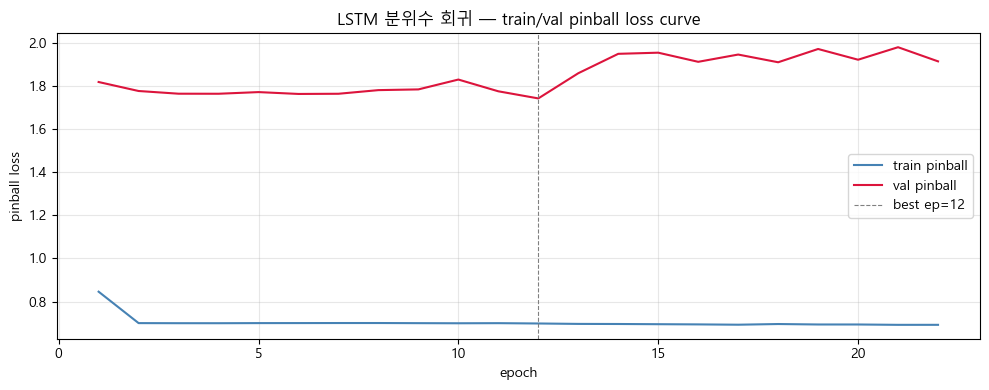

💾 reports/figures/w4_01_loss_curve.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ep_range = np.arange(1, len(history['train']) + 1)
ax.plot(ep_range, history['train'], label='train pinball', color='steelblue')
ax.plot(ep_range, history['val'],   label='val pinball',   color='crimson')
best_ep = int(np.argmin(history['val'])) + 1
ax.axvline(best_ep, color='gray', linestyle='--', linewidth=0.8, label=f'best ep={best_ep}')
ax.set_xlabel('epoch')
ax.set_ylabel('pinball loss')
ax.set_title('LSTM 분위수 회귀 — train/val pinball loss curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'w4_01_loss_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'💾 reports/figures/w4_01_loss_curve.png')

---

## 7. Monotonicity 점검 + sort 후처리 (계획서 §5.3)

In [8]:
@torch.no_grad()
def predict_quantiles(model, Xs):
    model.eval()
    xb = torch.from_numpy(Xs).float().to(DEVICE)
    pred = model(xb).cpu().numpy()  # (N, 3)
    return {q: pred[:, i] for i, q in enumerate(QUANTILES)}

preds_by_split = {
    'train': predict_quantiles(model, Xs_train),
    'val':   predict_quantiles(model, Xs_val),
    'test':  predict_quantiles(model, Xs_test),
}
ys_by_split = {'train': ys_train, 'val': ys_val, 'test': ys_test}

def count_crossings(p):
    arr = np.column_stack([p[q] for q in QUANTILES])
    n_05_50 = int(np.sum(arr[:, 0] > arr[:, 1]))
    n_50_95 = int(np.sum(arr[:, 1] > arr[:, 2]))
    return n_05_50, n_50_95

def sort_quantiles(p):
    arr = np.column_stack([p[q] for q in QUANTILES])
    arr_s = np.sort(arr, axis=1)
    return {q: arr_s[:, i] for i, q in enumerate(QUANTILES)}

preds_sorted_by_split = {}
for sp, p in preds_by_split.items():
    n1, n2 = count_crossings(p)
    total = len(p[0.05])
    print(f'{sp:6s}  N={total:>5d}  q05>q50: {n1:>4d} ({n1/total*100:.1f}%)  q50>q95: {n2:>4d} ({n2/total*100:.1f}%)')
    preds_sorted_by_split[sp] = sort_quantiles(p)

train   N= 2524  q05>q50:    0 (0.0%)  q50>q95:    0 (0.0%)
val     N=  205  q05>q50:    0 (0.0%)  q50>q95:    0 (0.0%)
test    N=  672  q05>q50:    0 (0.0%)  q50>q95:    0 (0.0%)


---

## 8. 평가 — Pinball / Coverage 90% / Sharpness / Dir_Acc (raw + sorted)

In [9]:
def pinball_np(y_true, y_pred, q):
    diff = y_true - y_pred
    return float(np.mean(np.maximum(q * diff, (q - 1) * diff)))

def dir_acc(y_true, y_pred):
    mask = (np.sign(y_pred) != 0) & (np.sign(y_true) != 0)
    if mask.sum() == 0: return float('nan')
    return float((np.sign(y_pred[mask]) == np.sign(y_true[mask])).mean())

def eval_split(p, y, label):
    out = {'split': label}
    for q in QUANTILES:
        out[f'pinball_q{int(q*100):02d}'] = pinball_np(y, p[q], q)
    cov = float(np.mean((y >= p[0.05]) & (y <= p[0.95])))
    sharp = float(np.mean(p[0.95] - p[0.05]))
    err = y - p[0.5]
    out['coverage_90'] = cov
    out['sharpness_bp'] = sharp
    out['rmse_q50_bp'] = float(np.sqrt(np.mean(err ** 2)))
    out['mae_q50_bp']  = float(np.mean(np.abs(err)))
    out['dir_acc_q50'] = dir_acc(y, p[0.5])
    return out

rows_raw, rows_sorted = [], []
for sp in ['train', 'val', 'test']:
    rows_raw.append(eval_split(preds_by_split[sp],        ys_by_split[sp], sp))
    rows_sorted.append(eval_split(preds_sorted_by_split[sp], ys_by_split[sp], sp))

eval_raw    = pd.DataFrame(rows_raw).round(3)
eval_sorted = pd.DataFrame(rows_sorted).round(3)
print('=== LSTM 분위수 회귀 — raw ===')
print(eval_raw.to_string(index=False))
print('\n=== LSTM 분위수 회귀 — sorted ===')
print(eval_sorted.to_string(index=False))

eval_path = REPORT_DIR / 'lstm_quantile_eval_w4.csv'
eval_combined = pd.concat([
    eval_raw.assign(stage='raw'),
    eval_sorted.assign(stage='sorted'),
], ignore_index=True)
eval_combined.to_csv(eval_path, index=False)
print(f'\n💾 {eval_path.relative_to(PROJECT_ROOT)}')

=== LSTM 분위수 회귀 — raw ===
split  pinball_q05  pinball_q50  pinball_q95  coverage_90  sharpness_bp  rmse_q50_bp  mae_q50_bp  dir_acc_q50
train        0.414        1.275        0.408        0.916        12.138        3.572       2.551        0.512
  val        1.093        2.881        1.288        0.615        11.861        7.390       5.761        0.456
 test        0.511        1.696        0.526        0.824        11.114        4.535       3.391        0.495

=== LSTM 분위수 회귀 — sorted ===
split  pinball_q05  pinball_q50  pinball_q95  coverage_90  sharpness_bp  rmse_q50_bp  mae_q50_bp  dir_acc_q50
train        0.414        1.275        0.408        0.916        12.138        3.572       2.551        0.512
  val        1.093        2.881        1.288        0.615        11.861        7.390       5.761        0.456
 test        0.511        1.696        0.526        0.824        11.114        4.535       3.391        0.495

💾 reports\lstm_quantile_eval_w4.csv


---

## 9. Naive · ARIMA · XGBoost(W3) · **LSTM(W4)** 비교

In [10]:
lstm_rows = []
for sp in ['train', 'val', 'test']:
    p = preds_sorted_by_split[sp]
    y = ys_by_split[sp]
    err = y - p[0.5]
    lstm_rows.append({
        'model': 'LSTM(q50)', 'split': sp,
        'RMSE_bp': round(float(np.sqrt(np.mean(err**2))), 3),
        'MAE_bp':  round(float(np.mean(np.abs(err))), 3),
        'Dir_Acc': round(dir_acc(y, p[0.5]), 3) if not np.isnan(dir_acc(y, p[0.5])) else float('nan'),
    })
lstm_df = pd.DataFrame(lstm_rows)

baseline_w4 = pd.concat([baseline_w3, lstm_df], ignore_index=True)
out_w4 = REPORT_DIR / 'baseline_results_w4.csv'
baseline_w4.to_csv(out_w4, index=False)

print('=== W4 통합 비교 ===')
print(baseline_w4.to_string(index=False))
print(f'\n💾 {out_w4.relative_to(PROJECT_ROOT)}')

# 핵심 비교 (val/test, 점추정 기준)
print('\n=== val/test 핵심 비교 ===')
core = baseline_w4[baseline_w4['model'].isin(['Naive (Δŷ=0)', 'ARIMA(1, 0, 1)', 'XGBoost(q50)', 'LSTM(q50)'])]
core = core[core['split'].isin(['val', 'test'])]
print(core.to_string(index=False))

=== W4 통합 비교 ===
         model split  RMSE_bp  MAE_bp  Dir_Acc
  Naive (Δŷ=0) train    3.606   2.571      NaN
  Naive (Δŷ=0)   cal    3.502   2.631      NaN
  Naive (Δŷ=0)   val    7.101   5.483      NaN
  Naive (Δŷ=0)  test    4.647   3.477      NaN
ARIMA(1, 0, 1) train    3.603   2.579    0.515
ARIMA(1, 0, 1)   cal    3.517   2.643    0.473
ARIMA(1, 0, 1)   val    7.114   5.500    0.431
ARIMA(1, 0, 1)  test    4.651   3.483    0.497
  XGBoost(q50) train    3.493   2.445    0.808
  XGBoost(q50)   val    7.075   5.455    0.509
  XGBoost(q50)  test    4.644   3.469    0.512
     LSTM(q50) train    3.572   2.551    0.512
     LSTM(q50)   val    7.390   5.761    0.456
     LSTM(q50)  test    4.535   3.391    0.495

💾 reports\baseline_results_w4.csv

=== val/test 핵심 비교 ===
         model split  RMSE_bp  MAE_bp  Dir_Acc
  Naive (Δŷ=0)   val    7.101   5.483      NaN
  Naive (Δŷ=0)  test    4.647   3.477      NaN
ARIMA(1, 0, 1)   val    7.114   5.500    0.431
ARIMA(1, 0, 1)  test    4.651  

---

## 10. 시각화 — 분위수 밴드 + RMSE 비교

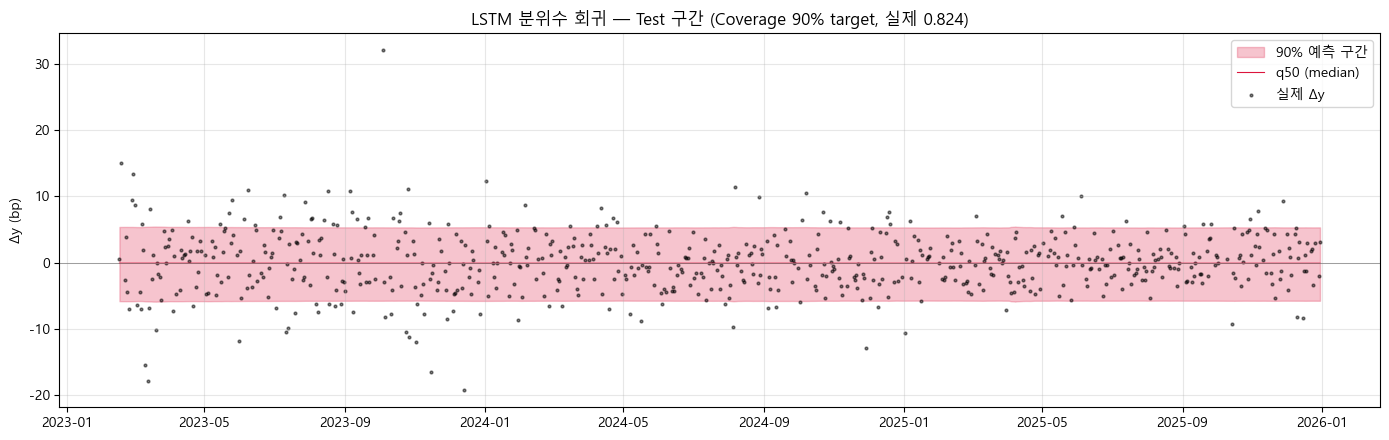

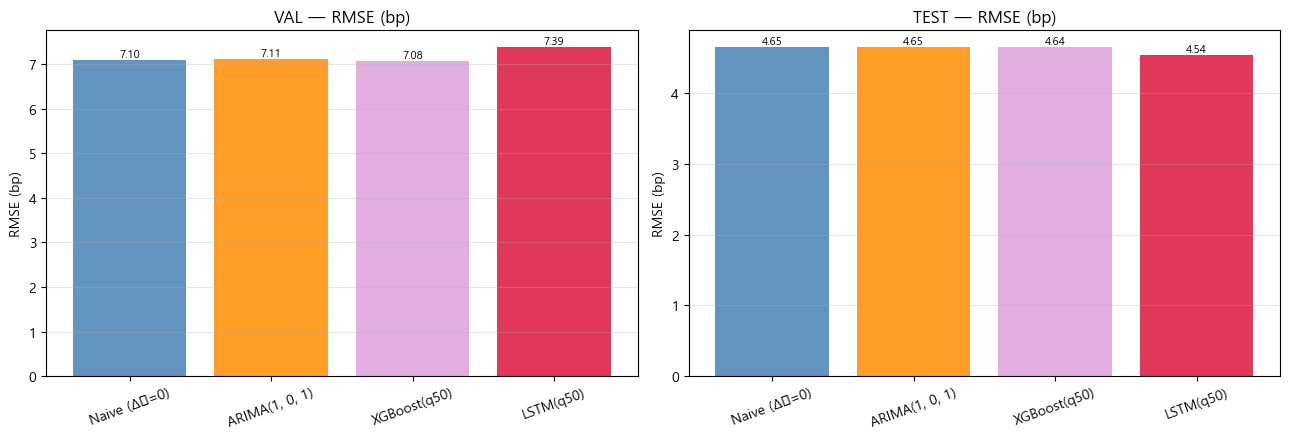

In [11]:
# (1) Test 구간 분위수 밴드
fig, ax = plt.subplots(figsize=(14, 4.5))
ps = preds_sorted_by_split['test']
ax.fill_between(dt_test, ps[0.05], ps[0.95], alpha=0.25, color='crimson', label='90% 예측 구간')
ax.plot(dt_test, ps[0.5], color='crimson', linewidth=0.8, label='q50 (median)')
ax.scatter(dt_test, ys_test, s=4, color='black', alpha=0.5, label='실제 Δy')
ax.axhline(0, color='gray', linewidth=0.5)
test_cov = float(np.mean((ys_test >= ps[0.05]) & (ys_test <= ps[0.95])))
ax.set_title(f'LSTM 분위수 회귀 — Test 구간 (Coverage 90% target, 실제 {test_cov:.3f})')
ax.set_ylabel('Δy (bp)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'w4_02_lstm_quantile_bands_test.png', dpi=120, bbox_inches='tight')
plt.show()

# (2) RMSE 비교 — val/test
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
model_colors = {
    'Naive (Δŷ=0)':           'steelblue',
    'Momentum (Δŷ=Δy_lag1)':  'seagreen',
    'ARIMA(1, 0, 1)':         'darkorange',
    'XGBoost(q50)':           'plum',
    'LSTM(q50)':              'crimson',
}
for ax, sp in zip(axes, ['val', 'test']):
    sub = baseline_w4[(baseline_w4['split']==sp) & baseline_w4['RMSE_bp'].notna()]
    bar_colors = [model_colors.get(m, 'gray') for m in sub['model']]
    ax.bar(sub['model'], sub['RMSE_bp'], color=bar_colors, alpha=0.85)
    ax.set_title(f'{sp.upper()} — RMSE (bp)')
    ax.set_ylabel('RMSE (bp)')
    for i, v in enumerate(sub['RMSE_bp'].values):
        ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'w4_05_rmse_compare.png', dpi=120, bbox_inches='tight')
plt.show()

---

## 11. **LSTM-SHAP DeepExplainer** (계획서 §6.2)

- DeepExplainer 는 PyTorch LSTM + 3D 입력에서 종종 실패 → **try/except 후 Permutation Importance 백업**.
- 계획서 위험 표 (§10): "LSTM-SHAP 호환 실패 시 Permutation Importance" 백업 명시.

### 분석 대상
- q05/q50/q95 중 q50 1개에 대해 변수 중요도 산출 (시간 절약)
- Background sample: train 200개, Eval sample: test 100개

In [12]:
import shap
print(f'shap {shap.__version__}')

rng = np.random.default_rng(SEED)
bg_idx   = rng.choice(len(Xs_train), size=min(200, len(Xs_train)), replace=False)
eval_idx = rng.choice(len(Xs_test),  size=min(100, len(Xs_test)),  replace=False)
Xs_bg   = Xs_train[bg_idx]
Xs_eval = Xs_test[eval_idx]
print(f'background: {Xs_bg.shape}, eval: {Xs_eval.shape}')

# q50 만 출력하는 wrapper
class Q50Wrap(nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base = base
    def forward(self, x):
        return self.base(x)[:, 1:2]   # q50 컬럼 (B,1)

wrap = Q50Wrap(model).to(DEVICE).eval()

shap_method_used = None
shap_values_lstm = None
shap_error_msg = None

try:
    bg_t   = torch.from_numpy(Xs_bg).float().to(DEVICE)
    eval_t = torch.from_numpy(Xs_eval).float().to(DEVICE)
    explainer = shap.DeepExplainer(wrap, bg_t)
    sv = explainer.shap_values(eval_t, check_additivity=False)
    if isinstance(sv, list):
        sv = sv[0]
    sv = np.asarray(sv)
    # squeeze trailing singleton output dim if present: (N,T,F,1)→(N,T,F)
    if sv.ndim == 4 and sv.shape[-1] == 1:
        sv = sv[..., 0]
    if sv.shape != Xs_eval.shape:
        raise ValueError(f'shap_values shape {sv.shape} != Xs_eval {Xs_eval.shape}')
    shap_values_lstm = sv  # (N, T, F)
    shap_method_used = 'DeepExplainer'
    print(f'✅ DeepExplainer 동작. shap_values shape: {sv.shape}')
except Exception as e:
    shap_error_msg = f'{type(e).__name__}: {e}'
    print(f'⚠️ DeepExplainer 실패 → Permutation Importance 백업 진입')
    print(f'   오류: {shap_error_msg[:200]}')

shap 0.51.0
background: (200, 30, 8), eval: (100, 30, 8)


✅ DeepExplainer 동작. shap_values shape: (100, 30, 8)


### 11b. Permutation Importance 백업 (DeepExplainer 실패 시 자동 진입)

각 변수 차원 `f` 의 시계열을 셔플 → q50 pinball loss 증가량을 중요도로 사용.

In [13]:
if shap_method_used is None:
    @torch.no_grad()
    def q50_pinball_for_array(Xs_arr, ys_arr):
        xb = torch.from_numpy(Xs_arr).float().to(DEVICE)
        pred = model(xb).cpu().numpy()[:, 1]   # q50
        return float(pinball_np(ys_arr, pred, 0.5))
    base_loss = q50_pinball_for_array(Xs_test, ys_test)
    print(f'baseline q50 pinball (test): {base_loss:.4f}')

    rng2 = np.random.default_rng(SEED)
    perm_imp = {}
    n_repeat = 5
    for f, fname in enumerate(FROZEN_W3):
        deltas = []
        for _ in range(n_repeat):
            Xs_perm = Xs_test.copy()
            # 변수 f 의 (N,T) 평면을 시퀀스 차원에 걸쳐 셔플
            flat = Xs_perm[:, :, f].reshape(-1)
            rng2.shuffle(flat)
            Xs_perm[:, :, f] = flat.reshape(Xs_perm.shape[0], Xs_perm.shape[1])
            perm_loss = q50_pinball_for_array(Xs_perm, ys_test)
            deltas.append(perm_loss - base_loss)
        perm_imp[fname] = float(np.mean(deltas))
    perm_series = pd.Series(perm_imp).sort_values(ascending=False)
    print('\nPermutation Importance (Δ q50 pinball, 양수일수록 중요):')
    print(perm_series.round(4).to_string())
    shap_method_used = 'PermutationImportance'
else:
    perm_series = None
    print(f'(DeepExplainer 성공 → Permutation Importance skip)')

(DeepExplainer 성공 → Permutation Importance skip)


### 11c. 변수 중요도 시각화 (SHAP 또는 Permutation)

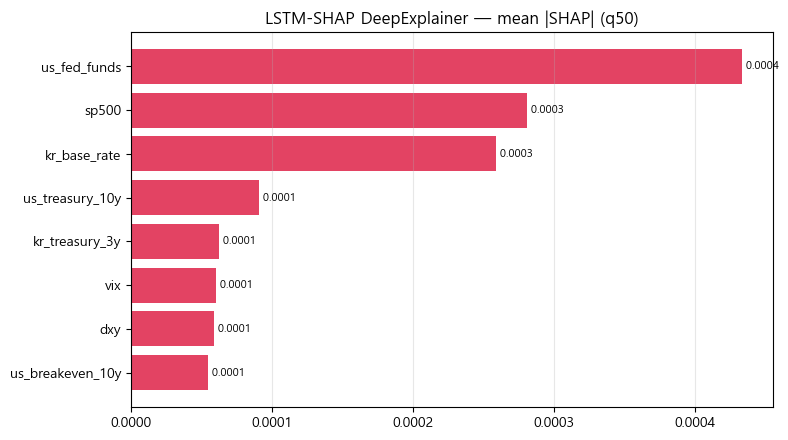

💾 reports\figures\w4_03_lstm_shap_bar.png
   method: DeepExplainer


In [14]:
if shap_values_lstm is not None:
    # |SHAP| 평균 — 시간/샘플 모두 평균해 변수별 단일 값
    mean_abs = np.abs(shap_values_lstm).mean(axis=(0, 1))   # (F,)
    imp_series = pd.Series(mean_abs, index=FROZEN_W3).sort_values(ascending=True)
    title = 'LSTM-SHAP DeepExplainer — mean |SHAP| (q50)'
    color = 'crimson'
elif perm_series is not None:
    imp_series = perm_series.sort_values(ascending=True)
    title = 'Permutation Importance (DeepExplainer 백업) — Δ q50 pinball'
    color = 'darkorange'
else:
    imp_series = None
    title = None

if imp_series is not None:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.barh(imp_series.index, imp_series.values, color=color, alpha=0.8)
    ax.set_title(title)
    ax.grid(alpha=0.3, axis='x')
    for i, v in enumerate(imp_series.values):
        ax.text(v, i, f' {v:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    fig_path = FIG_DIR / 'w4_03_lstm_shap_bar.png'
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'💾 {fig_path.relative_to(PROJECT_ROOT)}')
    print(f'   method: {shap_method_used}')

### 11d. (DeepExplainer 성공 시) 시간 lag별 |SHAP|

어떤 lag 위치에서 변수 영향이 강한지 시각화 — 한미 금리 시차 효과 (§6.3 Q1) 사전 검증.

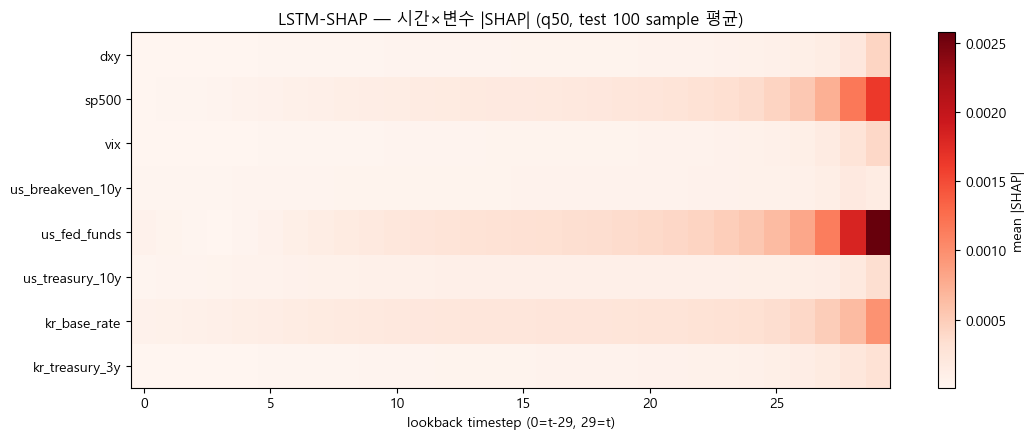

💾 reports\figures\w4_04_lstm_shap_time_heatmap.png


In [15]:
if shap_values_lstm is not None:
    mean_abs_t = np.abs(shap_values_lstm).mean(axis=0)   # (T, F)
    fig, ax = plt.subplots(figsize=(11, 4.5))
    im = ax.imshow(mean_abs_t.T, aspect='auto', cmap='Reds', origin='lower')
    ax.set_yticks(np.arange(len(FROZEN_W3)))
    ax.set_yticklabels(FROZEN_W3)
    ax.set_xlabel(f'lookback timestep (0=t-{LOOKBACK-1}, {LOOKBACK-1}=t)')
    ax.set_title('LSTM-SHAP — 시간×변수 |SHAP| (q50, test 100 sample 평균)')
    plt.colorbar(im, ax=ax, label='mean |SHAP|')
    plt.tight_layout()
    fig_path = FIG_DIR / 'w4_04_lstm_shap_time_heatmap.png'
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'💾 {fig_path.relative_to(PROJECT_ROOT)}')
else:
    print('(DeepExplainer 실패 → 시간 lag 히트맵 생성 불가, Permutation 백업만 사용)')

---

## 12. 산출물 저장 — LSTM 모델 + 예측 + SHAP 메타데이터

In [16]:
# (1) LSTM 가중치
ckpt_path = MODELS_DIR / 'lstm_quantile_w4.pt'
torch.save({
    'state_dict': model.state_dict(),
    'config': {
        'features': FROZEN_W3,
        'lookback': LOOKBACK,
        'lstm_cfg': dict(LSTM_CFG),
        'quantiles': QUANTILES,
        'best_epoch': int(np.argmin(history['val'])) + 1,
        'best_val_pinball': float(np.min(history['val'])),
    },
}, ckpt_path)
print(f'💾 {ckpt_path.relative_to(PROJECT_ROOT)}')

# (2) val/test 예측 + 점별 pinball (6주차 DM test 입력)
pred_rows = []
for sp_name, dates_arr, ys in [('val', dt_val, ys_val), ('test', dt_test, ys_test)]:
    ps = preds_sorted_by_split[sp_name]
    for date, true_v, p05, p50, p95 in zip(dates_arr, ys, ps[0.05], ps[0.5], ps[0.95]):
        pred_rows.append({
            'date': pd.Timestamp(date), 'split': sp_name,
            'y_true_bp': float(true_v),
            'q05': float(p05), 'q50': float(p50), 'q95': float(p95),
            'pinball_q05': max(0.05*(true_v-p05), -0.95*(true_v-p05)),
            'pinball_q50': max(0.5 *(true_v-p50), -0.5 *(true_v-p50)),
            'pinball_q95': max(0.95*(true_v-p95), -0.05*(true_v-p95)),
        })
pred_df = pd.DataFrame(pred_rows)
pred_path = DATA_DIR / 'processed' / 'lstm_predictions_w4.csv'
pred_df.to_csv(pred_path, index=False)
print(f'💾 {pred_path.relative_to(PROJECT_ROOT)}  ({len(pred_df):,}행)')

# (3) SHAP 메타데이터 (성공/실패 + 변수 중요도)
import json
shap_meta = {
    'method': shap_method_used,
    'error': shap_error_msg,
    'features': FROZEN_W3,
    'background_n': int(len(bg_idx)),
    'eval_n': int(len(eval_idx)),
    'importance_top': (imp_series.sort_values(ascending=False).round(6).to_dict()
                       if imp_series is not None else None),
}
shap_meta_path = REPORT_DIR / 'lstm_shap_meta_w4.json'
with open(shap_meta_path, 'w', encoding='utf-8') as f:
    json.dump(shap_meta, f, ensure_ascii=False, indent=2)
print(f'💾 {shap_meta_path.relative_to(PROJECT_ROOT)}')

💾 models\lstm_quantile_w4.pt
💾 data\processed\lstm_predictions_w4.csv  (877행)
💾 reports\lstm_shap_meta_w4.json


---

## 13. 다음 단계 (5주차 → `05_tuning_ablation.ipynb`)

1. **수동 grid 5×5** (학습률 5수준 × hidden 5수준) — `LSTM_CFG` 기반 격자 탐색
2. **환율 ablation A1** (필수, `docs/ablation_plan_w3.md`) — base 8 + krw_usd → 9 vars 재학습
3. (시간 여유 시) A2 kospi · A3 kr_ppi 중 1개
4. (선택) **CQR 후처리** — calibration 구간(2021)에서 보정 적용, val Coverage 회복 시도

### 본 노트북 산출물 → 5주차 입력

- `models/lstm_quantile_w4.pt` — 베이스 LSTM 가중치 (5주차 grid 탐색의 reference point)
- `data/processed/lstm_predictions_w4.csv` — 점별 pinball (6주차 DM test)
- `reports/lstm_quantile_eval_w4.csv` — raw vs sorted
- `reports/baseline_results_w4.csv` — Naive/ARIMA/XGBoost/**LSTM**
- `reports/figures/w4_01_loss_curve.png`, `w4_02_lstm_quantile_bands_test.png`,
  `w4_03_lstm_shap_bar.png` (+ DeepExplainer 성공 시 `w4_04_lstm_shap_time_heatmap.png`),
  `w4_05_rmse_compare.png`
- `reports/lstm_shap_meta_w4.json` — SHAP 메타데이터


### 🔄 5주차 진입 시 baseline 교체 (LOG #35 결정)
본 raw[t] LSTM 은 5주차에 **A0 (Δfeat[t-1]) LSTM 으로 baseline 교체**됨 (`docs/ablation_plan_w3.md` 참조).
본 결과 (test RMSE 4.535 ≈ Naive) 는 비정상 입력의 영향 측정 reference 로 보존되며, **메인 모델은 A0**.

### TODO (4주차 마감)

- [ ] §5 학습 + §7 monotonicity → `VALIDATION_LOG.md` 기록 (1건)
- [ ] §11 SHAP 시도 (성공/실패 무관) → `VALIDATION_LOG.md` 기록 (1건)